In [43]:
from pathlib import Path
import numpy as np
import pandas as pd

# K562 MPRA test set = fold 10, forward strand (see data/mpra/README.md)
mpra = pd.read_csv("/grid/koo/home/pmantill/projects/SEAM_validate/data/mpra/K562_averaged.tsv", sep="\t")
test = mpra[(mpra.fold == 10) & (mpra.rev == 0)].reset_index(drop=True)   # idx 0..len-1 == forward-strand position
print(f"test set: {len(test)} forward sequences")

test set: 19670 forward sequences


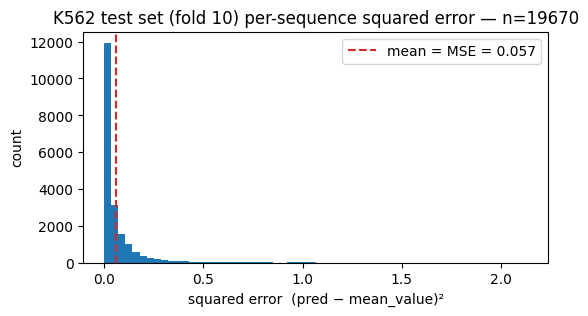

In [44]:
# per-sequence squared error across the full K562 test set (fold 10, forward)
import sys, torch
import matplotlib.pyplot as plt
sys.path.insert(0, "/grid/koo/home/pmantill/projects/Hippo_axis/Hippo_dependency_mpra/eigen-interactions")
from alphagenome_encoder_ft import EncoderMPRAModel

ckpt = "/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt"
cc = torch.load(ckpt, map_location="cpu", weights_only=False)["construct_config"]
suffix = cc["promoter_seq"] + cc["barcode_seq"]            # same 51bp suffix as the ISM cell
model = EncoderMPRAModel.from_checkpoint(ckpt, device="cuda").eval()

onehot = np.eye(4, dtype=np.float32)
test_preds = np.empty(len(test), dtype=np.float32)
bs = 256
with torch.no_grad():
    for i in range(0, len(test), bs):
        chunk = test.seq.iloc[i:i + bs]
        xb = torch.tensor(np.stack([onehot[["ACGT".index(c) for c in s + suffix]] for s in chunk])).cuda()
        test_preds[i:i + bs] = model(xb).squeeze(-1).cpu().numpy()

sq_err = (test_preds - test.mean_value.values) ** 2        # per-seq squared error
mse = sq_err.mean()

plt.figure(figsize=(6, 3))
plt.hist(sq_err, bins=60)
plt.axvline(mse, color="C3", ls="--", label=f"mean = MSE = {mse:.3f}")
plt.xlabel("squared error  (pred − mean_value)²"); plt.ylabel("count")
plt.title(f"K562 test set (fold 10) per-sequence squared error — n={len(test)}")
plt.legend();

In [45]:
# --- MSE cutoff: only sequences the model predicts well go forward ---
mse_cutoff = 0.05     # <-- edit this number to set your cutoff
keep = sq_err <= mse_cutoff                # boolean mask aligned to `test`
test_pass = test[keep].reset_index(drop=True)
print(f"cutoff = {mse_cutoff:.4f}  ->  keep {int(keep.sum())} / {len(test)} seqs "
      f"({100 * keep.mean():.1f}%)")

# --- seed selection: choose from seqs passing BOTH the MSE cut and an activity cut ---
act_cutoff = 1.5      # <-- min activity (mean_value)
pool = (test_pass[test_pass.mean_value >= act_cutoff]
        .sort_values("mean_value", ascending=False).reset_index(drop=True))
print(f"pool passing MSE <= {mse_cutoff:.4g} & activity >= {act_cutoff:.3g}: {len(pool)} seqs")

SEED_RANK = 0         # 0 = highest-activity seq in the pool; bump to pick the next one
seq = pool.iloc[SEED_RANK]
print(f"seed rank {SEED_RANK}:  {seq.seq_id}  mean_value={seq.mean_value:.4f}")
print(seq.seq)

cutoff = 0.0500  ->  keep 13519 / 19670 seqs (68.7%)
pool passing MSE <= 0.05 & activity >= 1.5: 8 seqs
seed rank 0:  peak27535_Reversed:  mean_value=1.9285
AGGACCGGATCAACTCATAAACTGTTTTTTTGATCTGATAACCAACACAGCTACGAAGTGCCTAACTTTGTAGCAGCCAGCGCATACAACATGCATATACTAGATAAAGGCTAACAGTTTACATCCTGGGTGGGACAGGGTGGGATGGTGCAAGATTTCATCATGCTACTCAGAATGAGGCACAATTTAAAATTTAGGCCGGGTGTGGTGGCTCCCATTGCGTGAACCGA


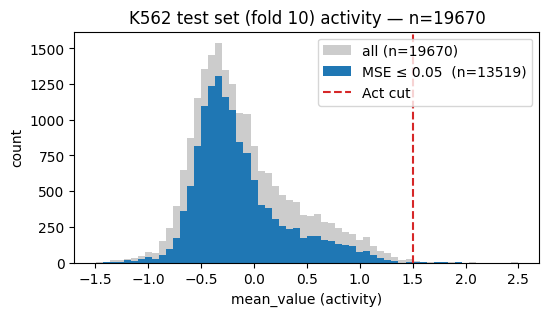

In [46]:
import matplotlib.pyplot as plt

bins = np.histogram_bin_edges(test.mean_value, bins=60)
plt.figure(figsize=(6, 3))
plt.hist(test.mean_value, bins=bins, color="0.8", label=f"all (n={len(test)})")
plt.hist(test.mean_value[keep], bins=bins, color="C0",
         label=f"MSE ≤ {mse_cutoff:.3g}  (n={int(keep.sum())})")
plt.axvline(act_cutoff, color="C3", ls="--", label="Act cut")
plt.xlabel("mean_value (activity)"); plt.ylabel("count")
plt.title(f"K562 test set (fold 10) activity — n={len(test)}")
plt.legend();

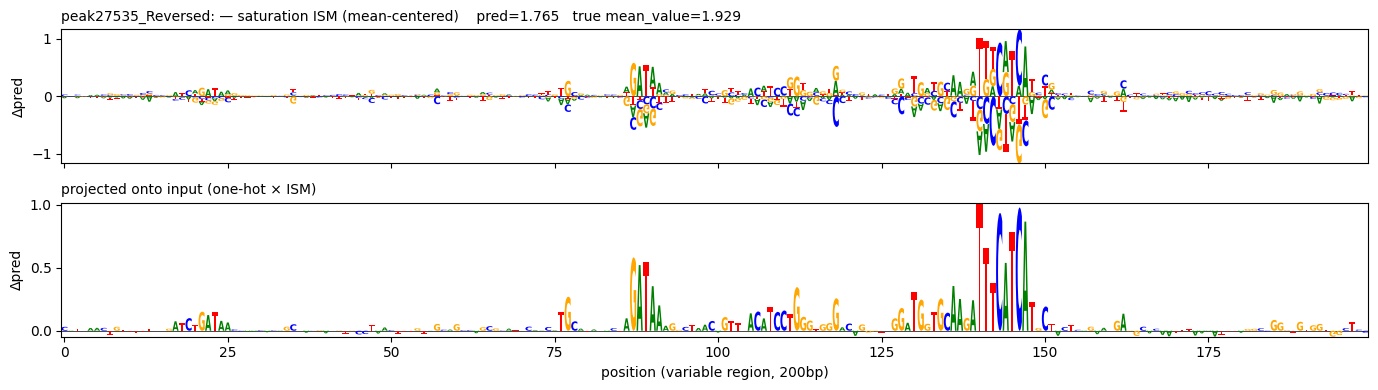

In [50]:
# simple saturation ISM for the selected test sequence
import sys, torch, logomaker
sys.path.insert(0, "/grid/koo/home/pmantill/projects/Hippo_axis/Hippo_dependency_mpra/eigen-interactions")
from alphagenome_encoder_ft import EncoderMPRAModel

ckpt = "/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt"
cc = torch.load(ckpt, map_location="cpu", weights_only=False)["construct_config"]
suffix = cc["promoter_seq"] + cc["barcode_seq"]            # 36bp promoter + 15bp barcode = 51bp
model = EncoderMPRAModel.from_checkpoint(ckpt, device="cuda").eval()

# mutant library: WT first, then every single-base substitution in the variable region [15:215]
lib = [seq.seq] + [seq.seq[:i] + b + seq.seq[i+1:] for i in range(15, 215) for b in "ACGT"]
onehot = np.eye(4, dtype=np.float32)
x = torch.tensor(np.stack([onehot[["ACGT".index(c) for c in s + suffix]] for s in lib])).cuda()

with torch.no_grad():
    preds = model(x).squeeze(-1).cpu().numpy()
ism = (preds[1:] - preds[0]).reshape(-1, 4)                # (200, 4) Δpred vs WT
ism -= ism.mean(-1, keepdims=True)                         # mean-center across channels

# project onto the observed sequence: one-hot × attribution (nonzero only at the WT base)
wt_var = onehot[["ACGT".index(c) for c in seq.seq[15:215]]]   # (200, 4)
proj = ism * wt_var

fig, (a1, a2) = plt.subplots(2, 1, figsize=(14, 4), sharex=True)
logomaker.Logo(pd.DataFrame(ism,  columns=list("ACGT")), ax=a1)
logomaker.Logo(pd.DataFrame(proj, columns=list("ACGT")), ax=a2)
a1.set_title(f"{seq.seq_id} — saturation ISM (mean-centered)    "
             f"pred={preds[0]:.3f}   true mean_value={seq.mean_value:.3f}", loc="left", fontsize=10)
a2.set_title("projected onto input (one-hot × ISM)", loc="left", fontsize=10)
a1.set_ylabel("Δpred"); a2.set_ylabel("Δpred")
a2.set_xlabel("position (variable region, 200bp)")
plt.tight_layout()

In [49]:
# run this cell to save the currently-selected seq as a SEAM seed (dedupes on seq)
reg_path = Path("/grid/koo/home/pmantill/projects/SEAM_validate/single_seq/seq_subsets/seam_seeds.csv")
row = {"seq_idx": int(test.index[test.seq.values == seq.seq][0]),
       "seq_id": seq.seq_id, "pred": float(preds[0]), "true": float(seq.mean_value), "seq": seq.seq}

df = pd.read_csv(reg_path) if reg_path.exists() else pd.DataFrame(columns=row)
if row["seq"] not in set(df.get("seq", [])):
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(reg_path, index=False)
print(f"saved -> {reg_path}  ({len(df)} seeds)")
df[["seq_idx", "seq_id", "pred", "true"]]

saved -> /grid/koo/home/pmantill/projects/SEAM_validate/single_seq/seq_subsets/seam_seeds.csv  (8 seeds)


,seq_idx,seq_id,pred,true
0,3609,peak27535_Reversed:,1.765135,1.9285
1,3320,peak26256,1.732207,1.7780
2,15776,peak84030,1.794500,1.7465
3,8467,peak49966_Reversed:,1.582142,1.7130
4,6001,peak38192_Reversed:,1.401627,1.5755
5,18024,ENSG00000143384,1.414394,1.5225
6,2074,peak20130,1.358207,1.5095
7,53,peak10288_Reversed:,1.640127,1.5065
